In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = "Y:\\jennifer\\spotiflow_mbl\\scripts\\outputs"
model_times = ["20250903_1715", "20251117_1545", "20251117_1539", "20251111_1157", "20251117_1538", "20251110_1639"]
point_priorities = ['unknown', 0.2, 0.4, 0.6, 0.8, 1.0]
window_sizes = [32, 48, 64]
# Create a mapping dictionary

models = []
model_names = []

for time, pp in zip(model_times, point_priorities):
    for ws in window_sizes:
        model_name = f"{ws}ws_{pp}pp"
        model = {"name": model_name, "time": time, "pp": pp, "ws": ws}
        models.append(model)
        model_names.append(model_name)

    
spot_stats_list = []
for model in models:
    spot_stats_path = f"Y:\\jennifer\\spotiflow_mbl\\scripts\\outputs\\spotiflow-{model['time']}\\spot_stats_{model['ws']}ws_0.1pt.csv"
    spot_stats = pd.read_csv(spot_stats_path)
    spot_stats_list.append(spot_stats)
    spot_stats["model_time"] = model["time"]
    spot_stats["point_priority"] = model["pp"]
    spot_stats["window_size"] = model["ws"]
    spot_stats["model_name"] = model["name"]


spot_stats = pd.concat(spot_stats_list, ignore_index=True)

In [72]:
spot_stats.head()

,dataset,frame_window,spot_id,spot_t,spot_y,spot_x,prob,TP/FP,early_detect,dist_err_xy,spot_z,dist_err_z,model_time,point_priority,window_size,model_name
0,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,0-32,0,20,1450,795,0.142818,FP,NaN,NaN,NaN,NaN,20250903_1715,unknown,32,32ws_unknownpp
1,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,0-32,1,24,536,1285,0.135398,FP,NaN,NaN,NaN,NaN,20250903_1715,unknown,32,32ws_unknownpp
2,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,0-32,2,22,688,207,0.103414,FP,NaN,NaN,NaN,NaN,20250903_1715,unknown,32,32ws_unknownpp
3,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,5-37,1,29,537,1284,0.189229,FP,NaN,NaN,NaN,NaN,20250903_1715,unknown,32,32ws_unknownpp
4,/groups/sgro/sgrolab/jennifer/cryolite/cryolit...,5-37,0,25,1449,796,0.155658,FP,NaN,NaN,NaN,NaN,20250903_1715,unknown,32,32ws_unknownpp


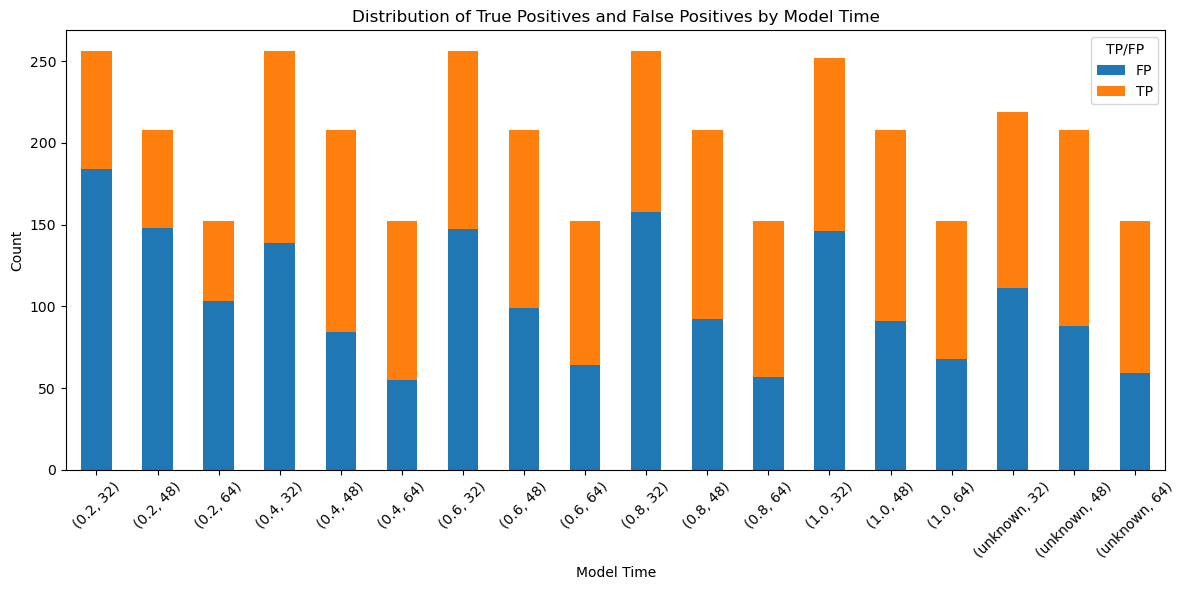

In [73]:
# make a stacked bar plot showing distribution of tps and fps for each model_time
plt.figure(figsize=(12, 6))

# Create a pivot table for stacked bar data
plot_data = spot_stats.groupby(['point_priority', 'window_size', 'TP/FP']).size().unstack(fill_value=0)

# Create stacked bar plot
plot_data.plot(kind='bar', stacked=True, ax=plt.gca())

plt.title('Distribution of True Positives and False Positives by Model Time')
plt.xlabel('Model Time')
plt.ylabel('Count')
plt.legend(title='TP/FP')
plt.xticks(rotation=45)
# plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()

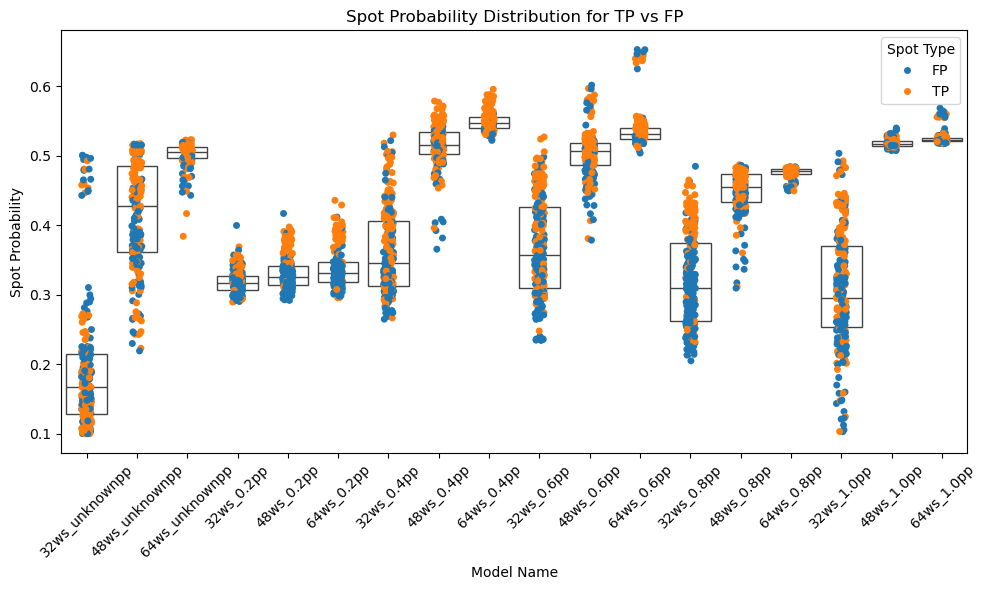

In [74]:
# make a swarm plot of prob for TP vs FP
plt.figure(figsize=(10,6))
sns.stripplot(x='model_name', y='prob', hue='TP/FP', data=spot_stats)
plt.title('Spot Probability Distribution for TP vs FP')
# add mean lines
ax = sns.boxplot(x='model_name', y='prob', data=spot_stats,
        showcaps=False, boxprops={'facecolor':'None'},
        showfliers=False, whiskerprops={'linewidth':0}
)
plt.ylabel('Spot Probability')
plt.xlabel('Model Name')
plt.xticks(rotation=45)
# plt.gca().set_xticklabels(model_names, rotation=45)
plt.legend(title='Spot Type')
plt.tight_layout()
plt.show()

In [75]:
# for each dataset, for each window, print tp or fp of the spot with the highest prob
# get list of unique values from spot_stats['dataset']
# Or set model_name as the index
combined_stats = pd.DataFrame(index=model_names, columns=['Top_Tps', 'Top_Fps', 'Top_TP_fraction', 'Top_FP_fraction'])
combined_stats = combined_stats.fillna(0)
for model_name in model_names:
    print(f"Analyzing model name: {model_name}")
    model_spot_stats = spot_stats[spot_stats['model_name'] == model_name]
    tps = 0
    fps = 0
    windows = 0
    datasets = model_spot_stats['dataset'].unique()
    for dataset in datasets:
        dataset_stats = model_spot_stats[model_spot_stats['dataset'] == dataset]
        frame_windows = dataset_stats['frame_window'].unique()
        for frame_window in frame_windows:
            windows += 1
            window_stats = dataset_stats[dataset_stats['frame_window'] == frame_window]
            max_prob_spot = window_stats.loc[window_stats['prob'].idxmax()]
            if max_prob_spot['TP/FP'] == "TP":
                tps += 1
            else:
                fps += 1

    combined_stats.at[model_name, 'Top_Tps'] = tps
    combined_stats.at[model_name, 'Top_Fps'] = fps
    tps_fraction = tps / windows
    fps_fraction = fps / windows
    combined_stats.at[model_name, 'Top_TP_fraction'] = tps_fraction
    combined_stats.at[model_name, 'Top_FP_fraction'] = fps_fraction
    print(f"Total TPs: {tps} ({tps_fraction:.2%}), Total FPs: {fps} ({fps_fraction:.2%})")


C:\Users\hillj\AppData\Local\Temp\ipykernel_20864\2359503979.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_stats = combined_stats.fillna(0)
C:\Users\hillj\AppData\Local\Temp\ipykernel_20864\2359503979.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_stats.at[model_name, 'Top_TP_fraction'] = tps_fraction
C:\Users\hillj\AppData\Local\Temp\ipykernel_20864\2359503979.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.75' has dtype incompatible with int64, please explicitly cast to a com

Analyzing model name: 32ws_unknownpp
Total TPs: 8 (25.00%), Total FPs: 24 (75.00%)
Analyzing model name: 48ws_unknownpp
Total TPs: 16 (61.54%), Total FPs: 10 (38.46%)
Analyzing model name: 64ws_unknownpp
Total TPs: 9 (47.37%), Total FPs: 10 (52.63%)
Analyzing model name: 32ws_0.2pp
Total TPs: 13 (40.62%), Total FPs: 19 (59.38%)
Analyzing model name: 48ws_0.2pp
Total TPs: 16 (61.54%), Total FPs: 10 (38.46%)
Analyzing model name: 64ws_0.2pp
Total TPs: 15 (78.95%), Total FPs: 4 (21.05%)
Analyzing model name: 32ws_0.4pp
Total TPs: 20 (62.50%), Total FPs: 12 (37.50%)
Analyzing model name: 48ws_0.4pp
Total TPs: 22 (84.62%), Total FPs: 4 (15.38%)
Analyzing model name: 64ws_0.4pp
Total TPs: 18 (94.74%), Total FPs: 1 (5.26%)
Analyzing model name: 32ws_0.6pp
Total TPs: 21 (65.62%), Total FPs: 11 (34.38%)
Analyzing model name: 48ws_0.6pp
Total TPs: 16 (61.54%), Total FPs: 10 (38.46%)
Analyzing model name: 64ws_0.6pp
Total TPs: 12 (63.16%), Total FPs: 7 (36.84%)
Analyzing model name: 32ws_0.8pp
To

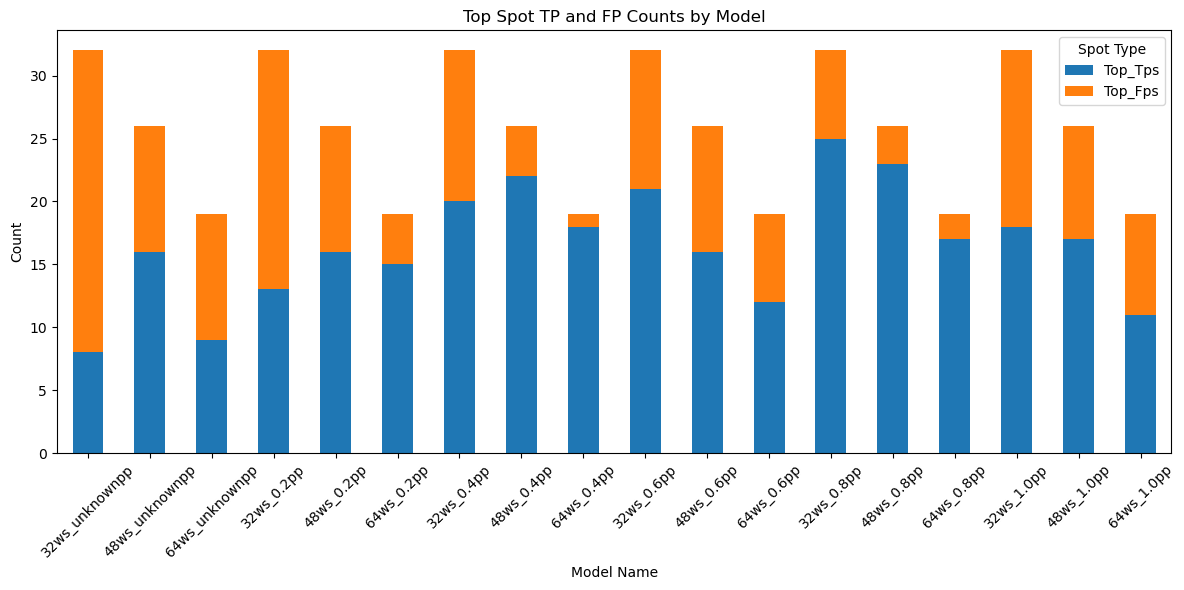

In [76]:
# Plot as stacked bar chart for each model time
plt.figure(figsize=(12, 6))
combined_stats[['Top_Tps', 'Top_Fps']].plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Top Spot TP and FP Counts by Model')
plt.xlabel('Model Name')
plt.ylabel('Count')
plt.legend(title='Spot Type')
plt.xticks(rotation=45)
# plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()

In [77]:
# track spots over time
# find all unique spot ids
combined_stats = pd.DataFrame(index=model_names, columns=['transient_TPs', 'transient_FPs', 'persistent_TPs', 'persistent_FPs'])
combined_stats = combined_stats.fillna(0)

for model_name in model_names:
    print(f"Analyzing model name: {model_name}")
    model_spot_stats = spot_stats[spot_stats['model_name'] == model_name]
    tps = 0
    fps = 0
    datasets = model_spot_stats['dataset'].unique()
    transient_tps = 0
    transient_fps = 0
    persistent_tps = 0
    persistent_fps = 0
    for dataset in datasets:
        dataset_stats = model_spot_stats[model_spot_stats['dataset'] == dataset]
        spot_ids = dataset_stats['spot_id'].unique()
        for spot_id in spot_ids:
            if pd.isna(spot_id):
                continue
            spot_data = dataset_stats[dataset_stats['spot_id'] == spot_id]

            if len(spot_data) <= 1:
                if spot_data['TP/FP'].values[0] == "TP":
                    transient_tps += 1
                else:
                    transient_fps += 1
            else:
                print(spot_data)
                if any(spot_data['TP/FP'] == "TP"):
                    persistent_tps += 1
                else:
                    persistent_fps += 1

    combined_stats.at[model_name, 'transient_TPs'] = transient_tps
    combined_stats.at[model_name, 'transient_FPs'] = transient_fps
    combined_stats.at[model_name, 'persistent_TPs'] = persistent_tps
    combined_stats.at[model_name, 'persistent_FPs'] = persistent_fps

    print(f"Unique Spots - Temporary TPs: {transient_tps}, Temporary FPs: {transient_fps}, Persistent TPs: {persistent_tps}, Persistent FPs: {persistent_fps}")

C:\Users\hillj\AppData\Local\Temp\ipykernel_20864\1935473297.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_stats = combined_stats.fillna(0)


Analyzing model name: 32ws_unknownpp
                                              dataset frame_window  spot_id  \
0   /groups/sgro/sgrolab/jennifer/cryolite/cryolit...         0-32        0   
4   /groups/sgro/sgrolab/jennifer/cryolite/cryolit...         5-37        0   
7   /groups/sgro/sgrolab/jennifer/cryolite/cryolit...        10-42        0   
10  /groups/sgro/sgrolab/jennifer/cryolite/cryolit...        15-47        0   
15  /groups/sgro/sgrolab/jennifer/cryolite/cryolit...        20-52        0   

    spot_t  spot_y  spot_x      prob TP/FP  early_detect  dist_err_xy  spot_z  \
0       20    1450     795  0.142818    FP           NaN          NaN     NaN   
4       25    1449     796  0.155658    FP           NaN          NaN     NaN   
7       31    1453     798  0.152615    FP           NaN          NaN     NaN   
10      38    1450     795  0.190466    FP           NaN          NaN     NaN   
15      41    1450     796  0.221353    FP           NaN          NaN     NaN   

 

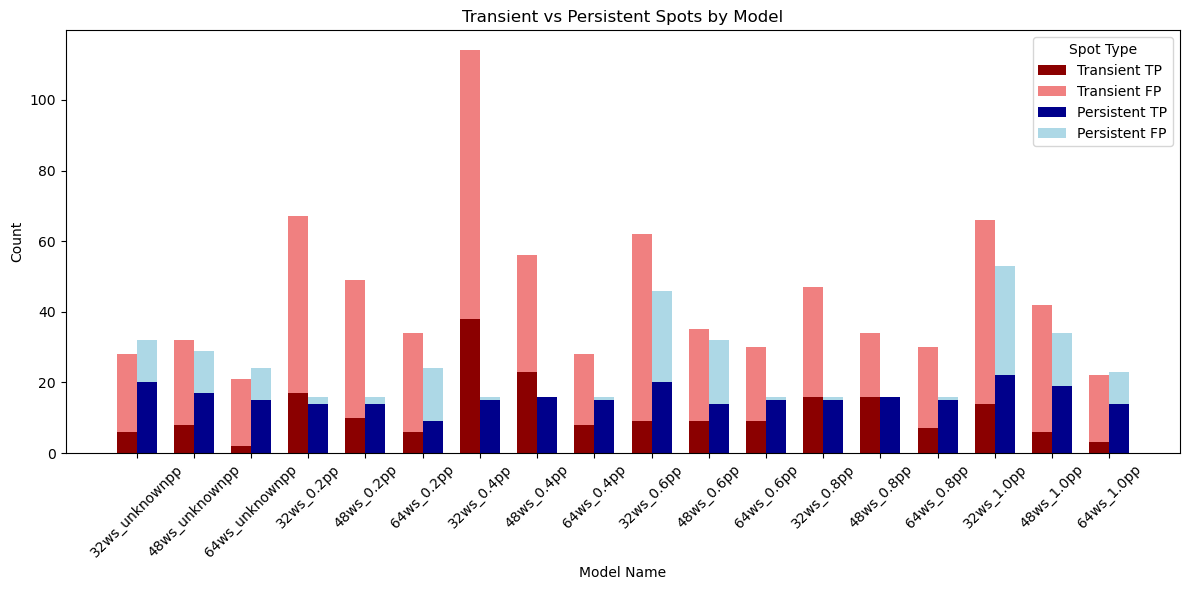

In [78]:
# plot persistent and transient spots as grouped stacked bar plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Reshape data for grouped stacked bars
x = np.arange(len(model_names))
width = 0.35

# Stack transients
tp_transient = combined_stats['transient_TPs'].values
fp_transient = combined_stats['transient_FPs'].values

# Stack persistents
tp_persistent = combined_stats['persistent_TPs'].values
fp_persistent = combined_stats['persistent_FPs'].values

# Create grouped bars
ax.bar(x - width/2, tp_transient, width, label='Transient TP', color='darkred')
ax.bar(x - width/2, fp_transient, width, bottom=tp_transient, label='Transient FP', color='lightcoral')

ax.bar(x + width/2, tp_persistent, width, label='Persistent TP', color='darkblue')
ax.bar(x + width/2, fp_persistent, width, bottom=tp_persistent, label='Persistent FP', color='lightblue')

ax.set_title('Transient vs Persistent Spots by Model')
ax.set_xlabel('Model Name')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)
ax.legend(title='Spot Type')

plt.tight_layout()
plt.show()

In [52]:
# TODO: plot as # of persistent frames vs TP/FP rate


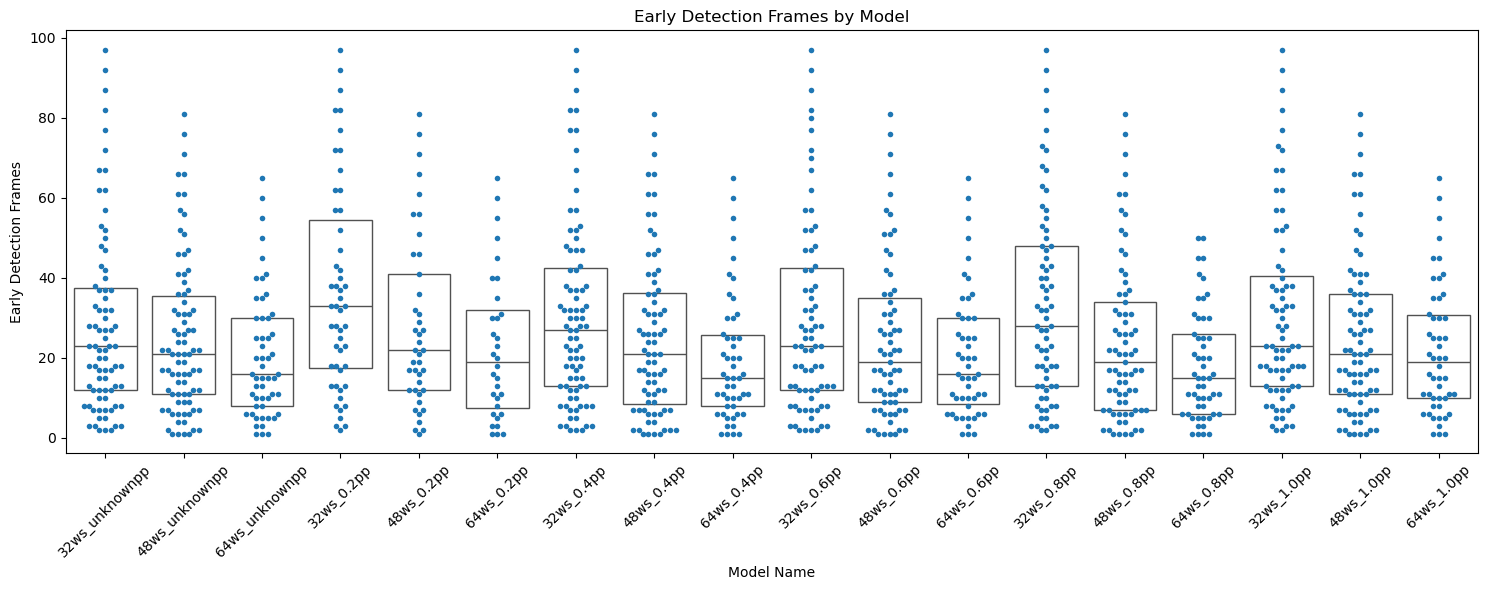

In [59]:
# scatter plot of early detection frames vs model time
plt.figure(figsize=(15,6))
sns.swarmplot(x='model_name', y='early_detect', data=spot_stats[spot_stats['early_detect'] > 0], size=4)
# add mean lines
ax = sns.boxplot(x='model_name', y='early_detect', data=spot_stats[spot_stats['early_detect'] > 0],
        showcaps=False, boxprops={'facecolor':'None'},
        showfliers=False, whiskerprops={'linewidth':0}
)
plt.title('Early Detection Frames by Model')
plt.xlabel('Model Name')
plt.ylabel('Early Detection Frames')
plt.xticks(rotation=45)
# plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()

c:\Users\hillj\AppData\Local\miniforge3\envs\spotiflow\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


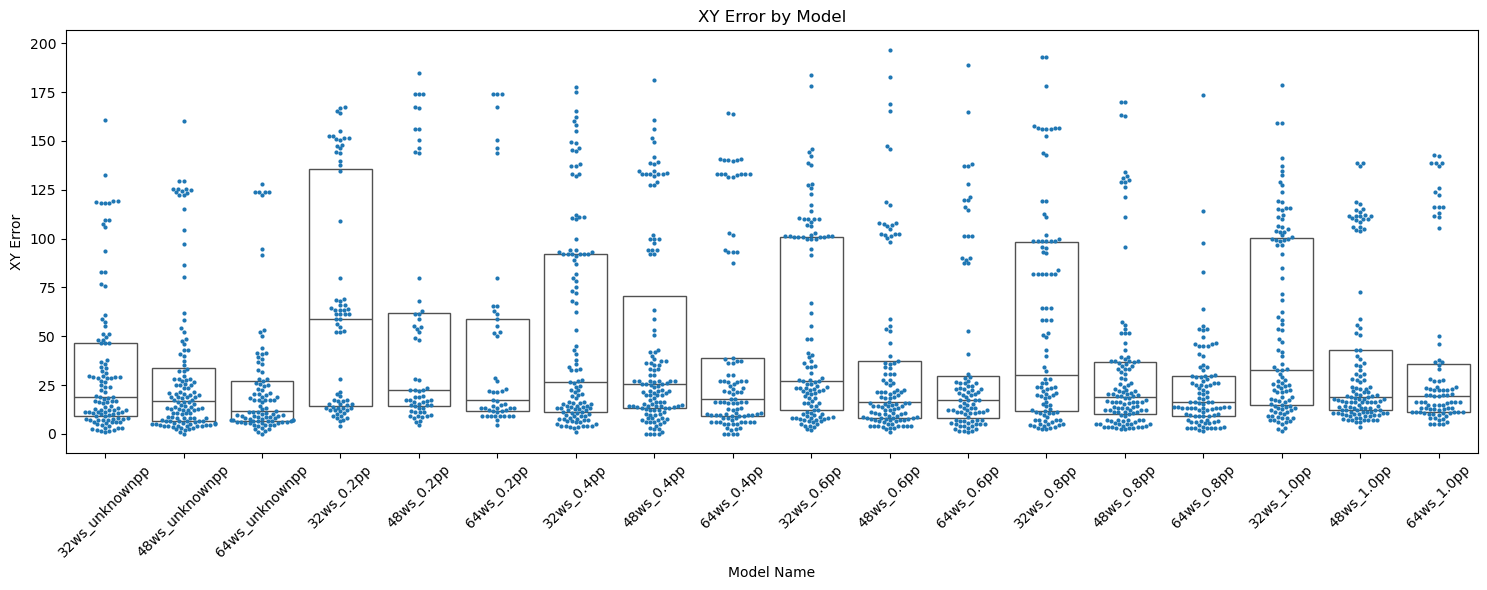

In [62]:
# scatter plot of xy_error vs model time
plt.figure(figsize=(15,6))
sns.swarmplot(x='model_name', y='dist_err_xy', data=spot_stats, size=3)
# add mean lines
ax = sns.boxplot(x='model_name', y='dist_err_xy', data=spot_stats,
        showcaps=False, boxprops={'facecolor':'None'},
        showfliers=False, whiskerprops={'linewidth':0}
)
plt.title('XY Error by Model')
plt.xlabel('Model Name')
plt.ylabel('XY Error')
plt.xticks(rotation=45)
# plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()

In [47]:
# calc average early_detect frames and dist_err_xy for TPs
combined_stats = pd.DataFrame(index=model_names, columns=['avg_early_detect', 'avg_dist_err_xy'])
combined_stats = combined_stats.fillna(0)
for model_name in model_names:
    model_stats = spot_stats[spot_stats['model_name'] == model_name]
    tp_stats = model_stats[model_stats['TP/FP'] == "TP"]
    # filter tps with early_detect < 0
    tp_stats = tp_stats[tp_stats['early_detect'] >= 0]
    avg_early_detect = tp_stats['early_detect'].mean()
    avg_dist_error_xy = tp_stats['dist_err_xy'].mean()
    combined_stats.at[model_name, 'avg_early_detect'] = avg_early_detect
    combined_stats.at[model_name, 'avg_dist_err_xy'] = avg_dist_error_xy
    print(f"Average early detection frames for TPs: {avg_early_detect:.2f}")
    print(f"Average XY distance error for TPs: {avg_dist_error_xy:.2f} pixels")

Average early detection frames for TPs: 28.18
Average XY distance error for TPs: 36.24 pixels
Average early detection frames for TPs: 25.09
Average XY distance error for TPs: 36.93 pixels
Average early detection frames for TPs: 19.46
Average XY distance error for TPs: 33.09 pixels
Average early detection frames for TPs: 36.84
Average XY distance error for TPs: 85.66 pixels
Average early detection frames for TPs: 28.10
Average XY distance error for TPs: 72.15 pixels
Average early detection frames for TPs: 22.62
Average XY distance error for TPs: 59.82 pixels
Average early detection frames for TPs: 30.24
Average XY distance error for TPs: 66.40 pixels
Average early detection frames for TPs: 25.46
Average XY distance error for TPs: 50.11 pixels
Average early detection frames for TPs: 18.45
Average XY distance error for TPs: 44.77 pixels
Average early detection frames for TPs: 29.45
Average XY distance error for TPs: 62.14 pixels
Average early detection frames for TPs: 24.36
Average XY dis

C:\Users\hillj\AppData\Local\Temp\ipykernel_20864\3101451048.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_stats = combined_stats.fillna(0)
C:\Users\hillj\AppData\Local\Temp\ipykernel_20864\3101451048.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '28.175' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_stats.at[model_name, 'avg_early_detect'] = avg_early_detect
C:\Users\hillj\AppData\Local\Temp\ipykernel_20864\3101451048.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '36.24143066411418' has dtype incompatible with int64, please expl

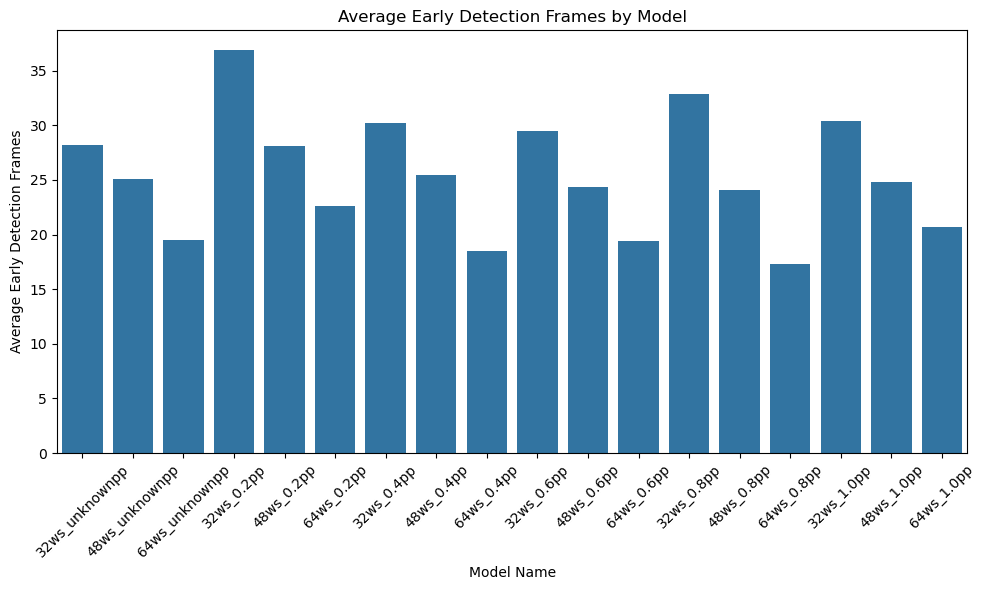

In [48]:
# Plot early detection for each model_time
plt.figure(figsize=(10,6))
sns.barplot(x=combined_stats.index, y='avg_early_detect', data=combined_stats)
plt.title('Average Early Detection Frames by Model')
plt.xlabel('Model Name')
plt.ylabel('Average Early Detection Frames')
plt.xticks(rotation=45)
# plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()

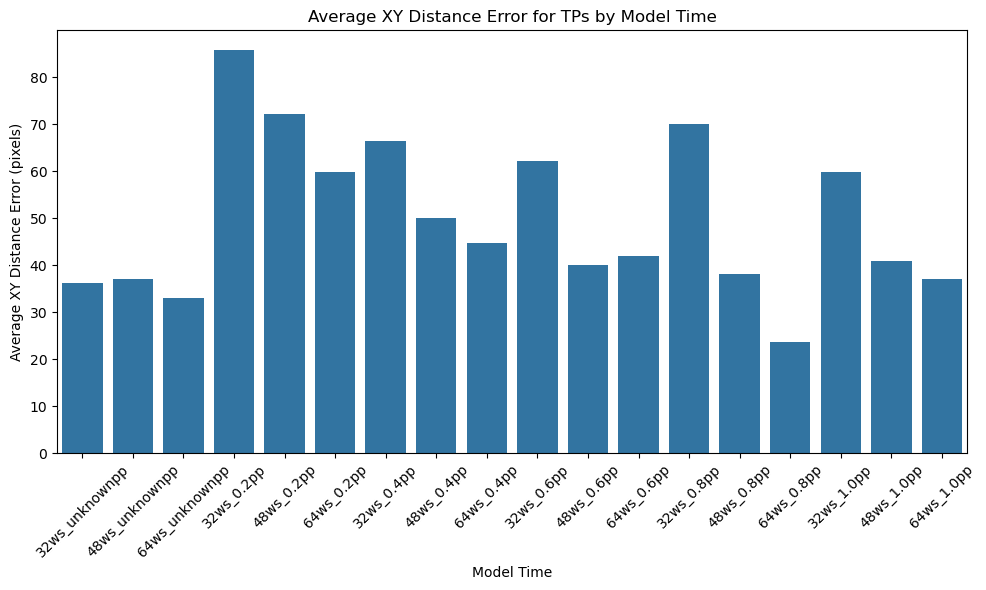

In [63]:
# Plot avg dist err xy for each model_time
plt.figure(figsize=(10,6))
sns.barplot(x=combined_stats.index, y='avg_dist_err_xy', data=combined_stats)
plt.title('Average XY Distance Error for TPs by Model Time')
plt.xlabel('Model Time')
plt.ylabel('Average XY Distance Error (pixels)')
plt.xticks(rotation=45)
# plt.gca().set_xticklabels(model_times, rotation=45)
plt.tight_layout()
plt.show()

In [68]:
# plot total number of z_spots vs model time
plot_data = spot_stats.groupby('model_name')['spot_z'].count()

plot_data.head()

model_name
32ws_0.2pp    54
32ws_0.4pp    89
32ws_0.6pp    89
32ws_0.8pp    79
32ws_1.0pp    87
Name: spot_z, dtype: int64

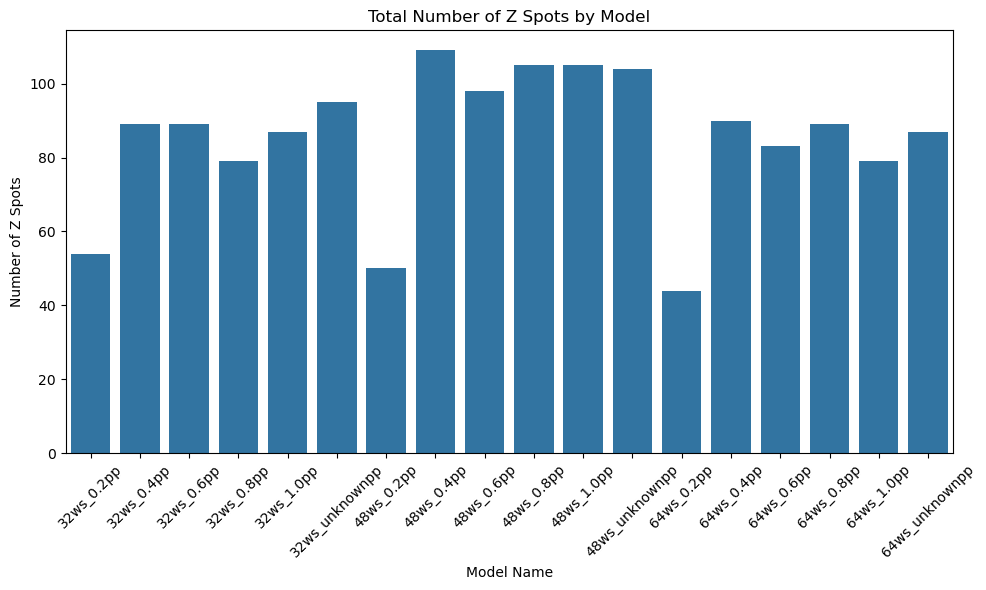

In [67]:
plt.figure(figsize=(10,6))
sns.barplot(x=plot_data.index, y=plot_data.values)
plt.title('Total Number of Z Spots by Model')
plt.xlabel('Model Name')
plt.ylabel('Number of Z Spots')
plt.xticks(rotation=45)
# plt.gca().set_xticklabels(model_names, rotation=45)
plt.tight_layout()
plt.show()